In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use("ggplot")
sns.set_theme()

In [4]:
df = pd.read_csv("../data/netflix_titles.csv")

In [5]:
df.head()

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.fillna("Unknown", inplace=True)

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

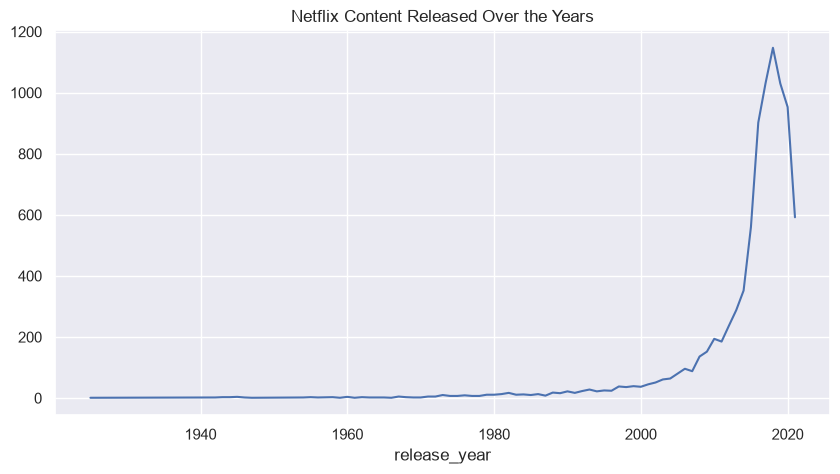

In [8]:
plt.figure(figsize=(10,5))

df["release_year"].value_counts().sort_index().plot()

plt.title("Netflix Content Released Over the Years")

plt.savefig("../images/content_growth.png")

plt.show()

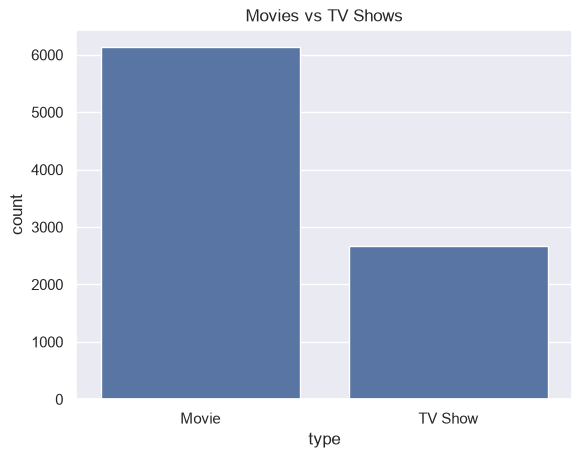

In [10]:
sns.countplot(data=df,x="type")

plt.title("Movies vs TV Shows")

plt.savefig("../images/movie_vs_tvshow.png")

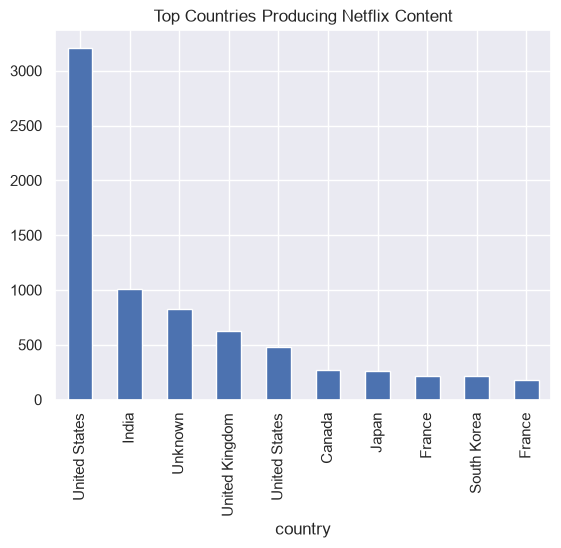

In [12]:
country=df["country"].str.split(",").explode()

country.value_counts().head(10).plot(kind="bar")

plt.title("Top Countries Producing Netflix Content")

plt.savefig("../images/top_countries.png")

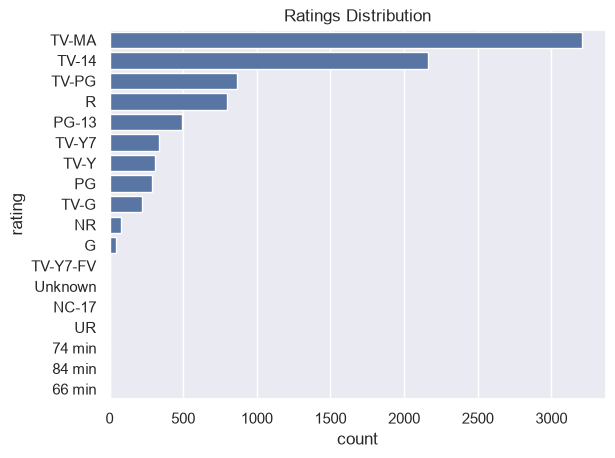

In [13]:
sns.countplot(y="rating",data=df,
              order=df["rating"].value_counts().index)

plt.title("Ratings Distribution")

plt.savefig("../images/ratings_distribution.png")

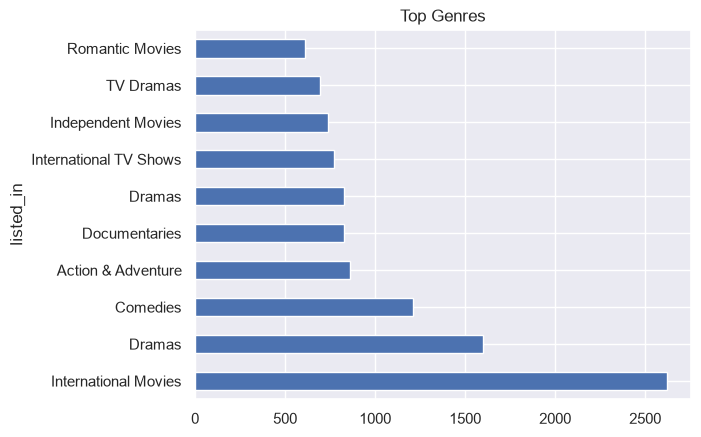

In [14]:
genre=df["listed_in"].str.split(",").explode()

genre.value_counts().head(10).plot(kind="barh")

plt.title("Top Genres")

plt.savefig("../images/top_genres.png")

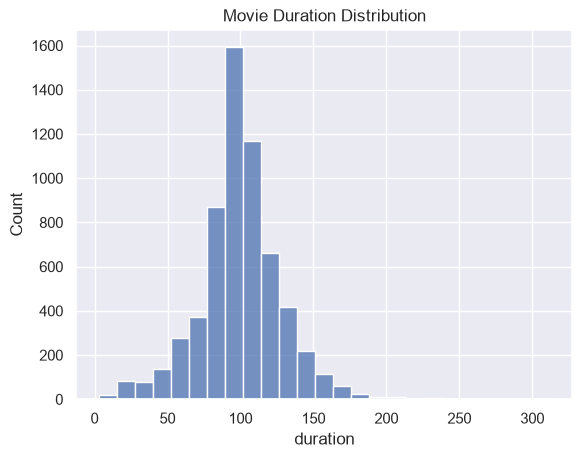

In [16]:
movies=df[df["type"]=="Movie"]

movies["duration"]=movies["duration"].str.replace(" min","")

movies["duration"]=pd.to_numeric(movies["duration"],errors="coerce")

sns.histplot(movies["duration"],bins=25)

plt.title("Movie Duration Distribution")

plt.savefig("../images/duration_distribution.png")

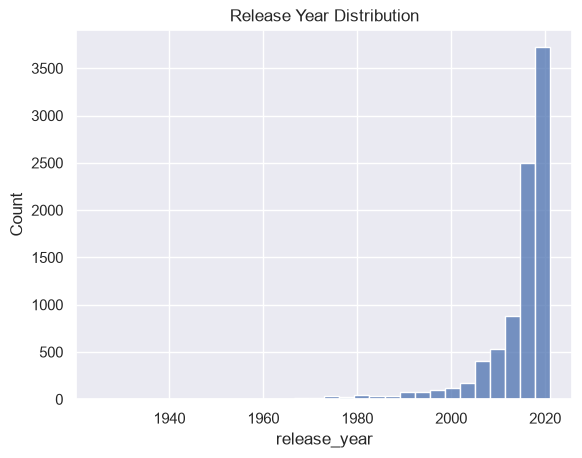

In [17]:
sns.histplot(df["release_year"],bins=30)

plt.title("Release Year Distribution")

plt.savefig("../images/release_year.png")

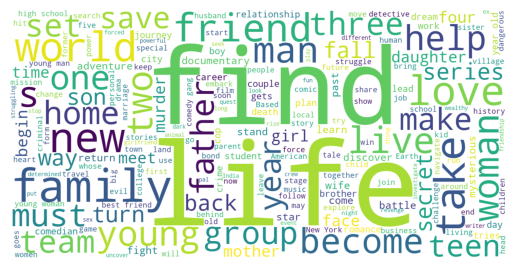

In [18]:
text=" ".join(df["description"].astype(str))

wc=WordCloud(width=1200,height=600,
             background_color="white").generate(text)

plt.imshow(wc)

plt.axis("off")

plt.savefig("../images/wordcloud_description.png")

Netflix has dramatically expanded its content after 2015.

Movies are significantly more common than TV shows.

The United States contributes the largest share of content.

Drama is the most popular genre.

Most movies have a runtime between 80 and 120 minutes.

The majority of Netflix content is targeted toward mature audiences.